# Minimum Absolute Difference in BST
Given the root of a Binary Search Tree (BST), return the minimum absolute difference between the values of any two different nodes in the tree.

[Leetcode Link](https://leetcode.com/problems/minimum-absolute-difference-in-bst/description/)

### Example 1
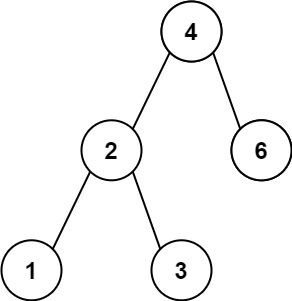

Input: root = [4,2,6,1,3]\
Output: 1

### Example 2
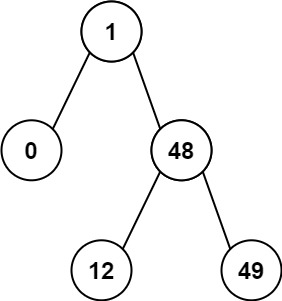

Input: root = [1,0,48,null,null,12,49]\
Output: 1

### Constraints
* The number of nodes in the tree is in the range [2, 104]
* 0 <= Node.val <= $10^{5}$

## Approach 1: Use Depth First Search and MergeSort
We will need to find all the nodes to make the comparison, which we could do with depth first search. Then, we could sort all the nodes we find and compare each node to the next greater node. After doing all the comparisons, we can return the minimum absolute difference we found between the nodes.  

### Analysis
* Time Complexity: O(N*log(N))
    * Doing the DFS will be O(N)
    * Doing all the comparisons would be O(N)
    * Sorting the nodes will be O(N*log(N)) which dominates the other operations
    * T(N) = N + N + N*log(N) = O(N*log(N))
    * this beats the brute-force solution of comparing all nodes to each other, which would be $O(N^{2})$ time complexity
* Space Complexity: O(N)
    * need to store an array of all the nodes to do the comparisons


In [ ]:
from typing import Optional
class TreeNode:
    def __init__(self, val=0, left=None, right=None):
        self.val = val
        self.left = left
        self.right = right

def getMinimumDifference(root: Optional[TreeNode]) -> int:
    all_nodes= []
    def dfs(root: Optional[TreeNode]):
        nonlocal all_nodes
        if root == None:
            return
        all_nodes.append(root.val)
        dfs(root.left)
        dfs(root.right)
        
    dfs(root)
    all_nodes = sorted(all_nodes)
    min_diff = min([all_nodes[i] - all_nodes[i-1] for i in range(1, len(all_nodes))])
    return min_diff

## Approach 2: Use InOrder Depth First Search
We can take advantage of the binary search tree property, and instead use inorder depth first search to get the nodes in order. Additionally, we can use a pointer of the previous node instead of a list when doing comparisons. This allows us to do the comparison when we visit the node.

### Analysis
* Time Complexity: O(N)
    * Inorder DFS is O(N)
* Space Complexity: O(log(N))
    * We still need to store space for the recursive stack when we perform DFS. The recursive stack will be the height of the tree
    * Average case where the tree is balanced: O(log(N))
    * Worst case where the tree is skewed: O(N)

In [ ]:
from typing import Optional
class TreeNode:
    def __init__(self, val=0, left=None, right=None):
        self.val = val
        self.left = left
        self.right = right

def getMinimumDifference(root: Optional[TreeNode]) -> int:
    last_node = None
    min_diff = float("inf")
    def dfs(root: Optional[TreeNode]):
        nonlocal last_node
        nonlocal min_diff
        if root == None:
            return
        dfs(root.left)
        if last_node:
            min_diff = min(min_diff, root.val- last_node.val)
        last_node = root
        dfs(root.right)
        
    dfs(root)
    return min_diff